In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import open3d as o3d
import numpy as np

class Real3DPointCloudDataset(Dataset):
    def __init__(self,num_points=1024):
        super().__init__()
        self.num_points=num_points

        self.mesh_bunny=o3d.data.BunnyMesh()
        self.mesh_armadillo=o3d.data.ArmadilloMesh()
        self.mesh_knot=o3d.data.KnotMesh()
#transform,assign lables
        self.data=[]
        self.labels=[]
        bunny=o3d.io.read_triangle_mesh(self.mesh_bunny.path)
        for _ in range(100):
            pcd=bunny.sample_points_uniformly(number_of_points=self.num_points)
            self.data.append(np.asarray(pcd.points))
            self.labels.append(0)
        armadillo=o3d.io.read_triangle_mesh(self.mesh_armadillo.path)
        for _ in range(100):
            pcd=armadillo.sample_points_uniformly(number_of_points=self.num_points)
            self.data.append(np.asarray(pcd.points))
            self.labels.append(1)
        knot=o3d.io.read_triangle_mesh(self.mesh_knot.path)
        for _ in range(100):
            pcd=knot.sample_points_uniformly(number_of_points=self.num_points)
            self.data.append(np.asarray(pcd.points))
            self.labels.append(2)
    def __len__(self):
        return len(self.data)
    def __getitem__(self,idx):
        points=torch.tensor(self.data[idx],dtype=torch.float32)
        label=torch.tensor(self.labels[idx],dtype=torch.long)
        return points,label
dataset = Real3DPointCloudDataset()
print(f"Dataset has been loaded successfully，Number of examples: {len(dataset)}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Dataset has been loaded successfully，Number of examples: 300


In [2]:
train_size=int(0.8*len(dataset))
test_size=len(dataset)-train_size
train_dataset,test_dataset=torch.utils.data.random_split(dataset,[train_size,test_size])
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)
print(f"{len(train_dataset)},{len(test_dataset)}")
print(f"{len(train_loader)}")

240,60
8


Epoch [1/10], Loss: 0.8966
Epoch [2/10], Loss: 0.2868
Epoch [3/10], Loss: 0.1665
Epoch [4/10], Loss: 0.0460
Epoch [5/10], Loss: 0.0050
Epoch [6/10], Loss: 0.0007
Epoch [7/10], Loss: 0.0002
Epoch [8/10], Loss: 0.0001
Epoch [9/10], Loss: 0.0001
Epoch [10/10], Loss: 0.0001

The accuracu of the test dataset: 100.00%


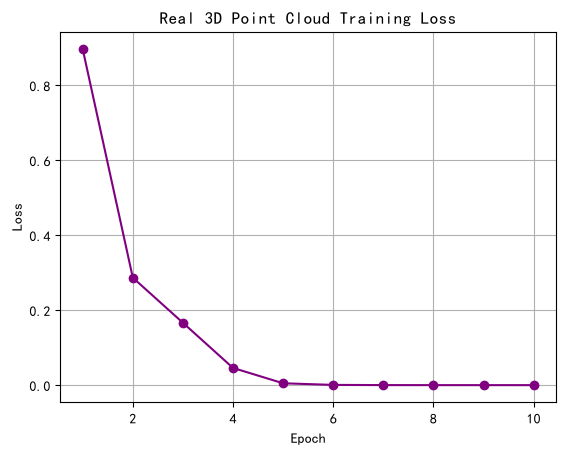

In [3]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


class MiniPointNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(3, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes) 
        )

    def forward(self, x):
        features = self.mlp(x)
        global_feature, _ = torch.max(features, dim=1)
        return self.classifier(global_feature)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniPointNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


epochs = 10
loss_history = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_points, batch_labels in train_loader:

        batch_points, batch_labels = batch_points.to(device), batch_labels.to(device)
        

        outputs = model(batch_points)
        loss = criterion(outputs, batch_labels)
        
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch_points, batch_labels in test_loader:
        batch_points, batch_labels = batch_points.to(device), batch_labels.to(device)
        outputs = model(batch_points)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

print(f"\nThe accuracu of the test dataset: {100 * correct / total:.2f}%")


plt.rcParams['font.sans-serif'] = ['SimHei']
plt.plot(range(1, epochs+1), loss_history, marker='o', color='purple')
plt.title("Real 3D Point Cloud Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [7]:
import open3d as o3d

bunny_mesh = o3d.io.read_triangle_mesh(o3d.data.BunnyMesh().path)
armadillo_mesh = o3d.io.read_triangle_mesh(o3d.data.ArmadilloMesh().path)
knot_mesh = o3d.io.read_triangle_mesh(o3d.data.KnotMesh().path)

bunny_mesh.scale(100, center=bunny_mesh.get_center())

bunny_mesh.translate((-100, 0, 0))
knot_mesh.translate((100, 0, 0))

bunny_mesh.paint_uniform_color([0.8, 0.2, 0.2])   # 红色
armadillo_mesh.paint_uniform_color([0.2, 0.8, 0.2]) # 绿色
knot_mesh.paint_uniform_color([0.2, 0.2, 0.8])    # 蓝色

o3d.visualization.draw_geometries(
    [bunny_mesh, armadillo_mesh, knot_mesh],
    window_name="3D Models: Bunny (Red), Armadillo (Green), Knot (Blue)",
    width=1024, height=768
)